In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_parquet('../data/processed/bookings_clean.parquet')
print("Shape:", df.shape)

Shape: (87389, 29)


In [2]:
X = df.drop(columns=['is_canceled'])
y = df['is_canceled']

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (87389, 28)
Target shape: (87389,)


In [3]:
cat_cols = X.select_dtypes(include='object').columns.tolist()
print("Categorical columns:", cat_cols)
print("Total:", len(cat_cols))

Categorical columns: ['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment', 'distribution_channel', 'reserved_room_type', 'assigned_room_type', 'deposit_type', 'customer_type']
Total: 10


In [4]:
le = LabelEncoder()

for col in cat_cols:
    X[col] = le.fit_transform(X[col])

print("Encoding done!")
print(X.dtypes.value_counts())

Encoding done!
int64      15
int32      10
float64     3
Name: count, dtype: int64


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training size:", X_train.shape)
print("Testing size:", X_test.shape)

Training size: (69911, 28)
Testing size: (17478, 28)


In [6]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Scaling done!")

Scaling done!


In [7]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("\nClassification Report:\n", classification_report(y_test, y_pred_lr))

Accuracy: 0.7765762673074722

Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.93      0.86     12779
           1       0.65      0.37      0.47      4699

    accuracy                           0.78     17478
   macro avg       0.72      0.65      0.66     17478
weighted avg       0.76      0.78      0.75     17478



In [8]:
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))

Accuracy: 0.8537590113285273

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.93      0.90     12779
           1       0.77      0.65      0.70      4699

    accuracy                           0.85     17478
   macro avg       0.82      0.79      0.80     17478
weighted avg       0.85      0.85      0.85     17478



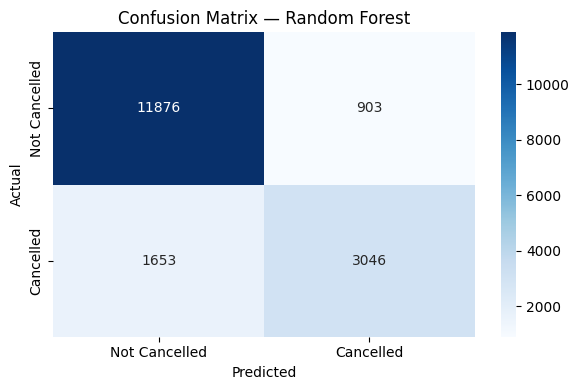

In [9]:
cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Cancelled', 'Cancelled'],
            yticklabels=['Not Cancelled', 'Cancelled'])
plt.title('Confusion Matrix — Random Forest')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('../outputs/figures/02_confusion_matrix.png', dpi=150)
plt.show()

C:\Users\lenovo\AppData\Local\Temp\ipykernel_13564\3082434097.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feat_importance.values, y=feat_importance.index, palette='Blues_r')


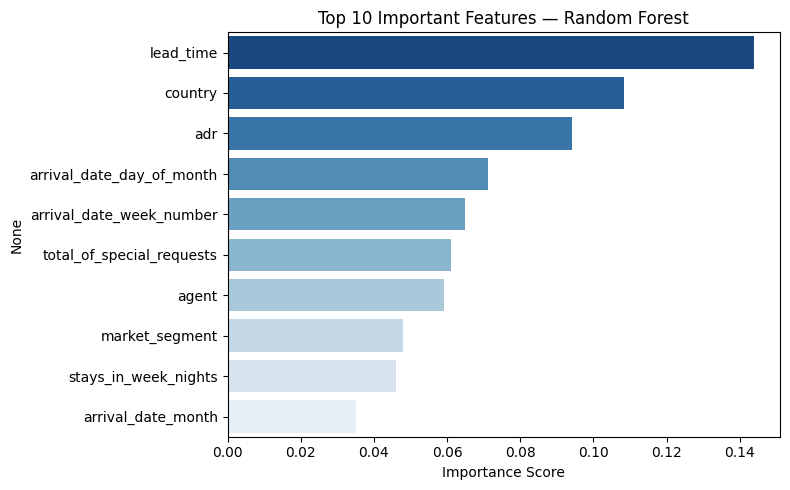

In [10]:
feat_importance = pd.Series(rf.feature_importances_, 
                            index=df.drop(columns=['is_canceled']).columns)
feat_importance = feat_importance.sort_values(ascending=False).head(10)

plt.figure(figsize=(8, 5))
sns.barplot(x=feat_importance.values, y=feat_importance.index, palette='Blues_r')
plt.title('Top 10 Important Features — Random Forest')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('../outputs/figures/03_feature_importance.png', dpi=150)
plt.show()

In [12]:
import joblib

joblib.dump(rf, '../models/random_forest_model.pkl')
joblib.dump(scaler, '../models/scaler.pkl')

print("Model and scaler saved!")

Model and scaler saved!
